# Import the libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

# Load the dataset

In [7]:
df = pd.read_csv(r'data/Social_Network_Ads.csv')

In [8]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


# Visualize Overfitting and Underfitting

In [9]:
def analyzer(max_depth):

    X = df.iloc[:, 2:4].values
    y = df.iloc[:, -1].values

    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(X, y)

    a = np.arange(start=X[:, 0].min() - 1, stop=X[:, 0].max() + 1, step=0.1)
    b = np.arange(start=X[:, 1].min() - 1, stop=X[:, 1].max() + 1, step=100)

    XX, YY = np.meshgrid(a, b)

    input_array = np.array([XX.ravel(), YY.ravel()]).T

    labels = dt.predict(input_array)

    plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y)

## Overfitting

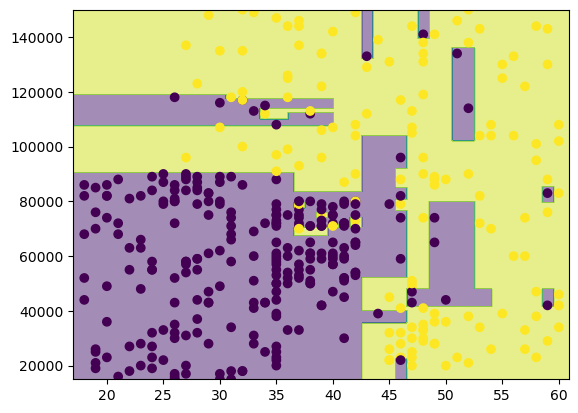

In [10]:
analyzer(max_depth=None)

* It is doing splits to reach till the leaf node. See the voilet point at (46, 0). If a new point comes in at it falls into this region, the it will be classified as blue but it should have been yellow.

## Underfitting

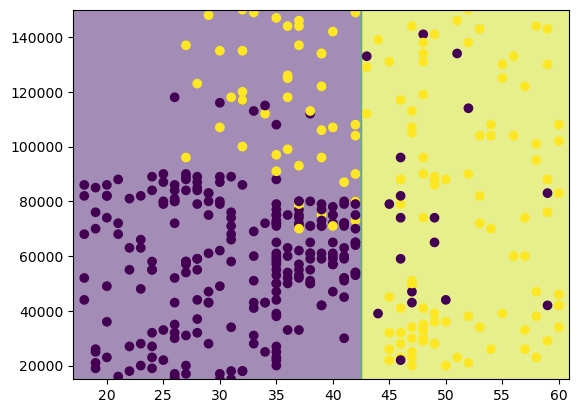

In [12]:
analyzer(max_depth=1)

* Alot of yellow points are in the voilet zone, model is underfitting. So if a new points comes and if it falls in this region, it will be classified as voilet but it should have been yellow actually.